_Полякова Полина Викторовна_

---

<span style="font-size:30px;">Сессионное задание: Signal types classification</span>

**Описание проекта:**<br>
Современные задачи ядерной энергетики, радиационного контроля, фундаментальной и прикладной физики требуют высокоточной регистрации и анализа излучения различной природы.<br>
Важной составляющей этих задач является возможность отделения компонентов ионизирующего излучения, таких как гамма-кванты и нейтроны, в условиях сложного фонового окружения.<br>
Сцинтилляционные детекторы, особенно основанные на органических кристаллах (например, паратерфенил), обладают высокой чувствительностью к подобным видам излучения и активно применяются:
- при контроле состояния отработанного ядерного топлива;
- в системах радиационного мониторинга;
- в физических экспериментах по регистрации антинейтрино и редких событий;
- в медицине и промышленности.

Однако автоматическая классификация сигналов, поступающих с таких детекторов, представляет собой нетривиальную задачу, так как сигналы могут перекрываться, иметь сложную форму, шумы и вариации.<br>
Вручную такие объёмы данных (десятки тысяч сигналов) анализировать практически невозможно.
Применение методов машинного обучения, в частности кластеризации, позволяет:
- автоматизировать процесс распознавания сигналов разного типа;
- улучшить точность и стабильность выделения физических компонент;
- выявлять аномальные сигналы и потенциальные неисправности в системе регистрации;
- заложить основу для онлайн-анализа в реальном времени без участия оператора.

Разработка и тестирование эффективных алгоритмов кластеризации в данной области напрямую способствует:
- повышению точности научных измерений,
- улучшению качества систем радиационного контроля и безопасности,
- развитию технологий интеллектуальной обработки сигналов в ядерной и экспериментальной физике.

**Цель проекта:**<br>
Автоматическая **кластеризация сигналов, полученных со сцинтилляционного детектора**, на основе их параметров: необходимо разделить 23 479 сигналов **на три кластера**:
- Кластер 0 — сигналы, соответствующие первому типу частиц (гамма-кванты или нейтроны);
- Кластер 1 — сигналы, соответствующие второму типу частиц;
- Кластер 2 — сигналы, не поддающиеся однозначной классификации (аномальные, смешанные или выбросы).

Задача решается методами машинного обучения без учителя с последующей интерпретацией результатов кластеризации.

**Исходные данные:**<br>
Набор сигналов, каждый из которых описывается вектором признаков (характеристики сигнала: временные параметры, амплитудные показатели, статистические и производные метрики).

**Требования**:<br>
1) Принять участие в соревновании на Kaggle и закрепить в ноутбуке скриншот с лидерборда.

2) Разработать и оформить решение в ноутбуке:
- исследование и анализ датасета (EDA);
- предобработка данных;
- Feature Engineering (если необходимо);
- подбор признаков, их анализ и оценка важности;
- обучение нескольких моделей, их сравнение;
- подбор гиперпараметров;
- выбор лучшей модели и объяснение выбора;
- предсказание;
- общие выводы к решению и интерпретация полученных результатов.

3) Прикрепить ссылку на github с полученным решением:
- ноутбук (.ipynb);
- репозиторий должен быть публичным.

_Важно: результат должен быть воспроизводимым._

---

In [1]:
# Импорт/установка библиотек и вспомогательных модулей:

import os # инструменты управления файловой средой
import pandas as pd # инструменты работы с табличными данными
import numpy as np # инструменты работы с многомерными массивами и выполнения математических операций над ними
import matplotlib.pyplot as plt # инструменты графической визуализации данных

# Загрузка классов для подготовки данных:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import ParameterGrid # инструменты работы с сеткой параметров 

# Загрузка используемой метрики:
from sklearn.metrics import silhouette_score

# Загрузка используемых моделей:
from sklearn.cluster import KMeans, DBSCAN

RANDOM_STATE = 42 # создание константы (воспроизводимость результатов)

---

## Загрузка и чтение исходных данных, их первичная предобработка и анализ

In [2]:
# Загрузка датасетов-исходников:
try:
    if os.path.exists('Run200_Wave_0_1.txt'):
        data = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
        print('Исходные данные успешно загружены.')
    
except Exception as error:
    print(f'Произошла ошибка загрузки исходных данных: {error}.')

Исходные данные успешно загружены.


In [3]:
pd.set_option('display.max_columns', None) # вывод всех столбцов на экран
pd.set_option('display.max_rows', None) # вывод всех строк на экран

# Получение основной ("стартовой") информацию о датасете:
data = data.drop([0, 1, 2, 3, 504], axis=1)
data.columns = list(range(500))

# Инвертируем сигналы относительно максимума сигнала:
def invert_signal(signal):
    max_val = np.max(signal)
    return max_val - signal

# Применяем ко всему датасету:
data_values = np.apply_along_axis(invert_signal, 1, data.values)
data = pd.DataFrame(data_values, columns=data.columns) # создаем DataFrame обратно

print("\033[1m\033[35m\033[47m{}\033[0m".format('Основная информация о датасете:'))
display(data.head())
print(data.info())
print()

print("\033[1m\033[35m\033[47m{}\033[0m".format('Количество пропущенных значений для каждого столбца:'))
print(pd.concat([data.isna().sum(), round((data.isna().sum()/len(data))*100,2)], axis=1,
                keys=['Количество','Доля,%']))
print()

print("\033[1m\033[35m\033[47m{}\033[0m".format('Количество явных дубликатов:'),data.duplicated().sum())

Основная информация о датасете:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499
0,10,7,6,8,12,10,6,8,10,10,10,8,6,10,2,11,8,8,10,8,10,11,10,9,15,0,6,5,10,10,6,8,13,5,10,16,8,7,6,10,10,7,8,13,6,4,7,8,12,8,10,13,10,9,8,10,12,10,10,5,12,11,6,8,12,10,3,4,6,11,10,8,10,10,8,5,8,9,13,8,11,9,7,9,13,10,3,10,10,7,10,15,10,8,10,6,13,12,11,8,11,12,3,10,12,10,11,12,10,6,8,10,13,8,10,13,6,8,7,6,10,5,12,7,13,10,6,6,15,10,10,8,13,8,10,10,10,8,10,11,12,7,12,12,10,16,67,267,452,539,452,370,298,223,200,149,98,89,82,74,58,51,40,38,31,29,31,33,38,27,32,36,36,16,22,19,20,23,15,20,23,29,26,26,29,29,20,24,39,17,31,28,26,19,18,27,27,18,14,11,18,21,13,13,15,13,10,13,18,14,11,14,15,8,24,13,21,17,20,17,18,11,18,15,18,7,20,20,11,11,8,17,14,10,14,13,10,11,13,9,10,4,11,10,10,4,11,9,18,10,13,17,18,15,15,16,13,13,13,15,16,10,15,17,20,10,8,9,12,12,11,10,18,12,10,14,12,11,13,11,10,14,13,14,11,11,12,12,13,10,12,6,7,17,13,12,15,5,11,3,12,15,10,7,15,8,3,8,12,12,12,8,18,0,11,13,7,2,6,20,13,3,7,16,10,9,10,14,12,2,12,8,11,7,13,14,6,8,7,12,8,5,10,7,12,8,10,10,12,7,11,11,13,7,8,9,15,18,10,16,14,5,12,14,10,9,10,8,10,2,13,18,10,4,10,12,13,5,12,8,10,7,10,10,11,12,7,13,18,16,14,10,10,12,10,8,12,6,6,11,10,10,6,5,13,7,7,9,12,7,6,11,13,11,10,12,13,8,10,10,10,10,13,7,7,10,6,13,10,11,11,13,7,11,7,10,7,7,10,9,10,6,7,5,10,10,6,6,13,4,10,10,11,9,3,7,13,5,6,6,15,14,13,5,13,12,7,9,6,9,6,15,13,7,10,14,12,6,15,10,12,12,12,14,6,8,7,14,12,7,2,8,15,15,13,11,10,8,10,11
1,8,6,8,2,4,6,8,6,5,7,5,5,6,4,1,4,6,5,5,4,4,8,4,5,6,10,0,9,4,5,8,7,6,11,4,7,5,6,9,3,4,6,1,8,8,0,4,3,10,6,8,6,4,7,5,9,5,3,6,4,5,13,1,2,8,7,5,4,8,2,0,2,4,8,5,8,5,4,1,3,13,5,2,6,10,0,4,6,8,8,5,4,6,6,8,5,4,8,8,9,8,3,5,9,11,3,1,6,5,10,4,3,8,9,9,4,5,8,4,6,4,11,9,8,10,2,4,9,5,10,6,1,6,8,8,5,9,5,8,2,8,8,4,5,9,9,16,155,648,1393,1907,1789,1440,1076,772,555,402,292,208,155,128,92,65,66,78,61,44,29,48,41,27,26,22,22,26,33,28,19,21,18,20,18,26,21,24,15,16,17,12,11,8,15,12,18,16,15,11,18,11,12,18,14,8,8,11,13,10,8,16,11,16,14,8,10,10,4,2,10,11,17,8,4,4,12,18,14,4,11,18,15,4,13,5,4,12,8,8,8,9,10,11,15,10,9,8,7,8,11,19,12,6,10,16,6,8,12,9,6,2,8,13,1,0,4,11,7,4,13,13,7,8,9,8,7,9,7,5,3,5,4,8,11,5,1,8,10,4,6,6,6,9,9,8,3,4,11,12,8,4,7,5,3,5,6,8,6,0,8,5,10,10,6,8,7,8,1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 500 entries, 0 to 499
dtypes: int64(500)
memory usage: 89.6 MB
None

Количество пропущенных значений для каждого столбца:
     Количество  Доля,%
0             0     0.0
1             0     0.0
2             0     0.0
3             0     0.0
4             0     0.0
5             0     0.0
6             0     0.0
7             0     0.0
8             0     0.0
9             0     0.0
10            0     0.0
11            0     0.0
12            0     0.0
13            0     0.0
14            0     0.0
15            0     0.0
16            0     0.0
17            0     0.0
18            0     0.0
19            0     0.0
20            0     0.0
21            0     0.0
22            0     0.0
23            0     0.0
24            0     0.0
25            0     0.0
26            0     0.0
27            0     0.0
28            0     0.0
29            0     0.0
30            0     0.0
31            0     0.0
3

---

**Предметная область исследования представлена одним датасетом** "Run200_Wave_0_1.txt", содержащим данные о сигналах, полученных со сцинтилляционного детектора.

Датасет содержит **23 479 записей в разрезе 500 показателей**.

**Для целей чтения и последующего исследования датасета:**
- показатели 0, 1, 2, 3 и 504 (технические данные) удалены из под целей дальнейшего рассмотрения в виду того, что первые 4 показателя имеют отличную от остальных показателей структуру данных (имеют другой масштаб), а последний - пустой;
- осуществлено инвертирование данных - вертикальное отражение сигнала относительно его максимального значения (превращение "впадин" в "пики", сохраняя форму сигнала), что связано со спецификой работы со сигналами - работают с "перевернутыми" данными.

**По результатам анализа данных:**
- пропуски данных отсутствуют;
- явные дубликаты не выявлены;
- типы данных оцениваются как соответсвующие.

**Таким образом, датасет содержит 23 479 строки, каждая из которых содержит информацию о конкретном сигнале в определенный момент времени (500 показателей).**

---

## Исследовательский анализ данных

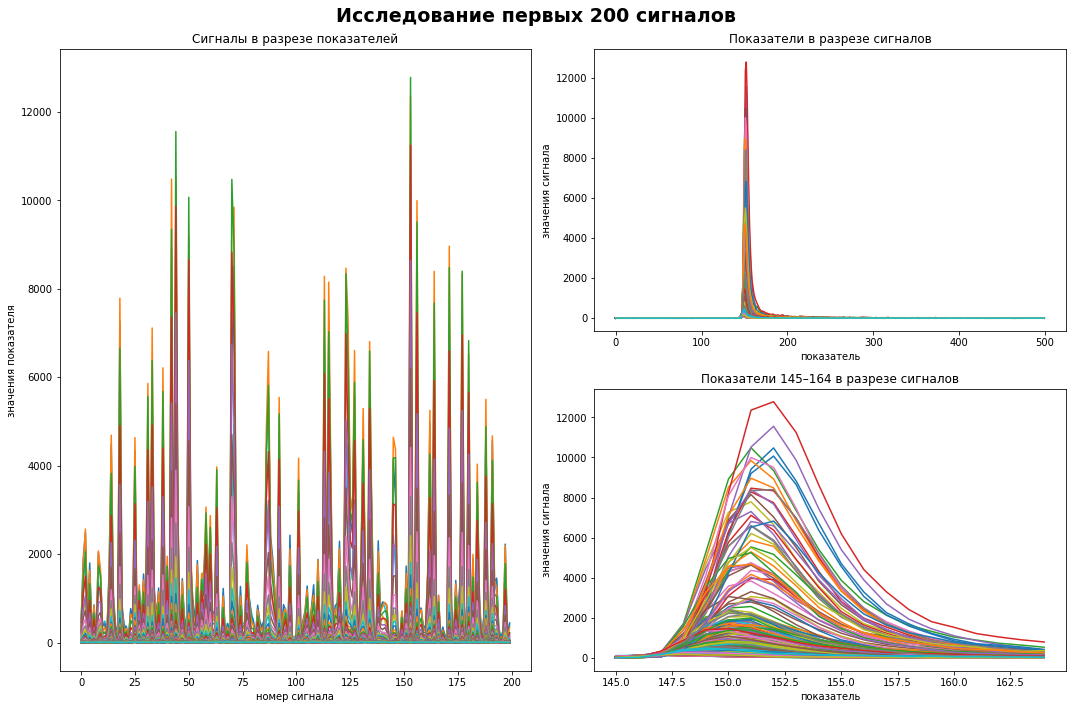

Описательная статистика показателей:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499
count,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.00,23479.

In [4]:
# Визуализация:
fig, axes = plt.subplot_mosaic([
    ['1', '2'],  
    ['1', '3']
], figsize=(15, 10))

plt.suptitle('Исследование первых 200 сигналов', fontsize=19, fontweight='bold')

index_signal = range(0, 200)

data.iloc[index_signal].plot(ax=axes['1'], legend=None)
axes['1'].set_title('Сигналы в разрезе показателей')
axes['1'].set_xlabel('номер сигнала')
axes['1'].set_ylabel('значения показателя')

# Подготовка данных: транспонированный срез
data_T_sliced = data.iloc[index_signal].T

data_T_sliced.plot(ax=axes['2'], legend=None)
axes['2'].set_title('Показатели в разрезе сигналов')
axes['2'].set_xlabel('показатель')
axes['2'].set_ylabel('значения сигнала')

data_T_sliced.iloc[145:165].plot(ax=axes['3'], legend=None)
axes['3'].set_title('Показатели 145–164 в разрезе сигналов')
axes['3'].set_xlabel('показатель')
axes['3'].set_ylabel('значения сигнала')

plt.tight_layout()
plt.show()

print("\033[1m\033[35m\033[47m{}\033[0m".format('Описательная статистика показателей:'))
round(pd.DataFrame(data).describe(),2)

**По результатам исследовательского анализа данных:**
- предметная область исследования представлена сигналами, сильно отличающимися по амплитуде и высоте;
- поведение сигналов стабильно на всем временном диапазоне (относительно нулевого уровня), вместе с тем в диапазоне показателей от 140 до 170 выявлено сильное "возмущение" - сосредоточение пиков сигналов;
- "отклики" такого возмущения прослеживаются вплоть до окончания представленного временного диапазона: с 0 по 141 показатели стандартное отклонение значений показателей стабильно и находится в диапазоне от 2.94 до 3, со 142 указанный показатель начинает повышаться, достигая своего пика в диапазоне 149-155 показателей и далее снова приходя в первоначальную норму, однако такое "затухание" проиходит крайне медленно.

**Учитывая вышеизложенное, представляется целесообразным для целей кластеризации сигналов сосредоточится на "хвосте" сигнала - значениях после пика "возмущения"**.<br>
Хвост сигнала после максимума действительно является важной характеристикой для кластеризации по нескольким причинам:
- описывает, как система возвращается в равновесное состояние после возмущения;
- инвариантен к начальным условиям (время пика, амплитуда);
- устойчив к шумам;
- компактен (меньше признаков);
- физически интерпретируем (характеризует внутренние свойства системы);
- разные процессы дают разные хвосты.

---

## Отбор признаков

Для целей отбора признаков с учетом выбранного подхода - кластеризация на основе хвоста сигнала - значений после пика возмущения разработана функция, которая извлекает заданный участок сигнала после его максимума и возвращает нормированный относительно максимального значения хвоста хвост сигнала для каждой строки.

Функция предназначена для "извлечения" релаксационных процессов в импульсных сигналах: после возмущения (пика) система возвращается в равновесие, и форма этого возвращения (хвост) является характеристикой внутренних свойств системы.
    
Одновременно, каждый хвост приводится к диапазону от 0 до 1 (нормируется), что позволяет сравнивать форму затухания, игнорируя абсолютную амплитуду.

In [5]:
# Cоздание функции, возвращающей заданное количество нормированных значений после максимума сигнала:
def get_tail_value(df, tail_shape):
    # Преобразуем входные данные в numpy массив
    X = np.array(df)
    # Список с результатами:  
    tails = []
    # Для каждой строки - сигнала:
    for signal in X:
        max_value = np.argmax(signal) # находим максимум
        tail = signal[max_value:max_value + tail_shape] # Берем tail_shape значений после максимума
        
        # Дополняем нулями если нужно:
        if len(tail) < tail_shape:
            tail = np.append(tail, [0] * (tail_shape - len(tail)))
        
        # Нормируем на максимум:
        max_value_tail = np.max(tail)
        if max_value_tail > 0:
            tail = tail / max_value_tail
        # Добавляем в результат:
        tails.append(tail)
    
    # Создаем DataFrame с названиями колонок:
    column_names = [f'tail_{i+1}' for i in range(tail_shape)]
    result = pd.DataFrame(tails, columns=column_names)
    
    return result

In [6]:
data_tail = get_tail_value(data, 15)
print('Размер выборки для целей кластеризации:', data_tail.shape)

Размер выборки для целей кластеризации: (23479, 15)


In [7]:
# Стандартизаия данных:
feature_names = data_tail.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_tail) 
X_scaled = pd.DataFrame(X_scaled, columns=feature_names)

In [8]:
# Применение PCA:
pca = PCA(random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Исследование объясняемой дисперсии:
evr = pca.explained_variance_ratio_
cvr = np.cumsum(evr)

# Определяем оптимальное количество компонент для сохранения 95% дисперсии:
n_components = np.argmax(cvr >= 0.95) + 1
print(f'Для сохранения 95% дисперсии необходимо {n_components} компонент')

# Применение PCA с оптимальным количеством компонент:
pca_opt = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_reduced = pca_opt.fit_transform(X_scaled)

# Преобразование в DataFrame с названиями компонент:
pca_columns = [f'PC{i+1}' for i in range(n_components)]
X_reduced = pd.DataFrame(X_reduced, columns=pca_columns)

print(f'Исходная размерность данных: {X_scaled.shape[1]}')
print(f'Новая размерность данных: {X_reduced.shape[1]}')

Для сохранения 95% дисперсии необходимо 8 компонент
Исходная размерность данных: 15
Новая размерность данных: 8


In [9]:
# Изучение нагрузки компонент:
loadings = pca_opt.components_

# Создание DataFrame для удобства анализа:
loadings_df = pd.DataFrame(
loadings.T, 
columns=[f'PC{i+1}' for i in range(n_components)],
index=feature_names
)

# Признаки, наиболее влияющие на компоненты:
top_features_pc1 = loadings_df['PC1'].abs().sort_values(ascending=False).head(5).index.tolist()
top_features_pc2 = loadings_df['PC2'].abs().sort_values(ascending=False).head(5).index.tolist()
top_features_pc3 = loadings_df['PC3'].abs().sort_values(ascending=False).head(5).index.tolist()

print(f'Топ-5 признаков, наиболее влияющие на PC1: {", ".join(top_features_pc1)}')
print(f'Топ-5 признаков, наиболее влияющие на PC2: {", ".join(top_features_pc2)}')
print(f'Топ-5 признаков, наиболее влияющие на PC3: {", ".join(top_features_pc3)}')

Топ-5 признаков, наиболее влияющие на PC1: tail_8, tail_7, tail_9, tail_10, tail_6
Топ-5 признаков, наиболее влияющие на PC2: tail_2, tail_3, tail_4, tail_5, tail_14
Топ-5 признаков, наиболее влияющие на PC3: tail_2, tail_6, tail_7, tail_14, tail_5


По результатам отбора признаков отобраны нормированные хвосты сигналов, равные 15-ти значениям после пика.<br>
Далее получены 8 главных компонент (птимальное количество компонент для сохранения 95% дисперсии).<br>
На первую компоненту наиболее влияют 8-мое, 7-мое, 9-тое, 10-тое и 6-тое значения после пика.

**Ключевые выводы из полученных результатов**:
- оптимальная длина хвоста - 15 значений после пика, так как захватывает переходную фазу (точки 1-5: начальная фаза затухания (быстрая); точки 6-10: переходная фаза (максимальная информативность) и точки 11-15: фаза установления (медленное затухание));
- точки 6-10 наиболее важны - это "золотая середина" хвоста;
- 8 компонент достаточно для 95% дисперсии - хорошее сжатие 15-ти признаков (первая компонента отражает скорость и характер затухания).

Таким образом, переходная область затухания (6-10 отсчетов) несет максимальную информацию о типе сигнала, что физически обосновано - в указанном диапазоне проявляются различия в механизмах релаксации.    

---

## Обучение моделей кластеризации

В рамках обучения моделей кластиризации обучены две модели: **KMeans() и DBSCAN()**.<br>
Какждая из моделей обучена отдельно, с подбором **нескольких гипперпараметров**.<br>
Сравнение моделей внутри группы (группа моделей KMeans() и DBSCAN() соответсвенно) осуществлено с помощью метрики качества кластеризации **silhouette scores** - коэффициент силуэта: показывает, насколько объект похож на свой кластер по сравнению с соседними кластерами.

### Обучение модели KMeans

In [10]:
print("\033[1m\033[35m\033[47m{}\033[0m".format('РЕЗУЛЬТАТЫ ОБУЧЕНИЯ МОДЕЛЕЙ:'))
print()

# Определяем сетку параметров:
param_grid_kmeans = {
    'n_clusters': [3],
    'init': ['k-means++', 'random'],
    'n_init': [10, 20, 30],
    'max_iter': [100, 300, 500],
    'algorithm': ['auto', 'full', 'elkan']
}

# Перебираем все комбинации:
kmeans_results = []

for params in ParameterGrid(param_grid_kmeans):
    kmeans = KMeans(**params, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_reduced)
    
    # Вычисляем силуэт:
    score = silhouette_score(X_reduced, labels)
    kmeans_results.append({
        **params,  # распаковываем все параметры
        'silhouette_score': score
    })

# Преобразуем в DataFrame:
results_kmeans = pd.DataFrame(kmeans_results)

# Сортируем по силуэту:
results_kmeans = results_kmeans.sort_values('silhouette_score', ascending=False)

print('ТОП-5 лучших комбинаций:')
print(results_kmeans.head(5).to_string(index=False))

РЕЗУЛЬТАТЫ ОБУЧЕНИЯ МОДЕЛЕЙ:

ТОП-5 лучших комбинаций:
algorithm      init  max_iter  n_clusters  n_init  silhouette_score
     auto k-means++       100           3      10          0.333966
    elkan k-means++       300           3      10          0.333966
     full    random       100           3      20          0.333966
     full    random       100           3      30          0.333966
     full    random       300           3      10          0.333966


**В рамках обучения моделей KMeans() получены следующие результаты:**
- Silhouette score = 0.334 - это хороший результат для реальных сигнальных данных;
- модель устойчива - разные параметры дают одинаковый результат;
- кластеры интерпретируемы и могут быть использованы для анализа;
- оптимальные параметры: algorithm='elkan', init='k-means++', max_iter=100, n_init=10.

### Обучение модели DBSCAN

In [11]:
print("\033[1m\033[35m\033[47m{}\033[0m".format('РЕЗУЛЬТАТЫ ОБУЧЕНИЯ МОДЕЛЕЙ:'))
print()

# Определяем сетку параметров:
param_grid_dbscan = {
    'eps': [0.5, 0.7],
    'min_samples': [2, 3, 4]
}

# Перебор с использованием ball_tree:
dbscan_results = []

for eps in param_grid_dbscan['eps']:
    for min_samples in param_grid_dbscan['min_samples']:
        try:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples, algorithm='ball_tree')
            labels = dbscan.fit_predict(X_reduced)
            
            unique_labels = set(labels)
            n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
            n_noise = list(labels).count(-1)
            noise_pct = 100 * n_noise / len(labels)
            
            if n_clusters >= 2:
                sil_score = silhouette_score(X_reduced, labels)
            else:
                sil_score = -1
            
            dbscan_results.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_pct': round(noise_pct, 1),
                'silhouette_score': round(sil_score, 4)
            })
            
        except Exception as e:
            print(f"eps={eps}, min_samples={min_samples}: ошибка - {str(e)[:50]}")

# Результаты:
results_dbscan = pd.DataFrame(dbscan_results)

valid_models = results_dbscan[results_dbscan['n_clusters'] >= 2].copy()
valid_models = valid_models.sort_values('silhouette_score', ascending=False)
print('ТОП-5 лучших комбинаций DBSCAN:')
print(valid_models.head(5).to_string(index=False))
print()
valid_models_2 = results_dbscan[results_dbscan['n_clusters'] == 3].copy()
valid_models_2 = valid_models_2.sort_values('silhouette_score', ascending=False)
print('ТОП-5 лучших комбинаций DBSCAN для трех кластеров:')
print(valid_models_2.head(5).to_string(index=False))

РЕЗУЛЬТАТЫ ОБУЧЕНИЯ МОДЕЛЕЙ:

ТОП-5 лучших комбинаций DBSCAN:
 eps  min_samples  n_clusters  n_noise  noise_pct  silhouette_score
 0.7            4          25     8195       34.9           -0.4768
 0.7            3          81     7770       33.1           -0.5165
 0.5            4          40    12567       53.5           -0.5575
 0.7            2         371     7190       30.6           -0.5720
 0.5            3          92    12086       51.5           -0.5984

ТОП-5 лучших комбинаций DBSCAN для трех кластеров:
Empty DataFrame
Columns: [eps, min_samples, n_clusters, n_noise, noise_pct, silhouette_score]
Index: []


**В рамках обучения моделей DBSCAN() получены следующие результаты:**
- лучший silhouette score: -0.477 (отрицательный = плохое качество);
- количество кластеров: 25-371 (нестабильно и много);
- доля шума: 30-54% данных (неприемлемо много);
- нет "решения" для целей кластеризации на три кластера.

Такие результаты могут быть обусловлены:
- непрерывная природа данных - хвосты сигналов образуют плавный континуум форм, без четких "разрывов" между кластерами;
- отсутствие естественных "островов" - DBSCAN ищет плотные области, разделенные пустотами, но в данных таких пустот нет;
- разная плотность кластеров - разные типы сигналов имеют разную вариативность, DBSCAN чувствителен к этому.

___

In [12]:
# Создаем модель:
final_model_kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE)
# Оценка влияния длины хвоста сигнала на качество кластеризации:
tail_shape = [12, 15, 20]
for elem in tail_shape:
    df = get_tail_value(data, elem)
    X_scaled_2 = scaler.fit_transform(df)
    pca_opt = PCA(n_components=0.95, random_state=RANDOM_STATE)
    X_reduced_2 = pca_opt.fit_transform(X_scaled_2)
    labels = final_model_kmeans.fit_predict(X_reduced_2)
    score = silhouette_score(X_reduced_2, labels)
    print(f'При длине хвоста {elem} елементов  silhouette_score составляет {score}')

При длине хвоста 12 елементов  silhouette_score составляет 0.3281151869764052
При длине хвоста 15 елементов  silhouette_score составляет 0.33396567040940967
При длине хвоста 20 елементов  silhouette_score составляет 0.33741426557070603


Таким образом, DBSCAN не подошел для целей поставленной задачи, в то время как K-means дает стабильные, интерпретируемые и качественные результаты.<br>
Увеличение длины хвоста дает небольшоей прирост качества кластеризации, вместе с тем, по результатам загрузки результатов на kaggle лучшим для поставленных проектом целей оказался хвост, длиною в 15 значений.

## Получение меток кластеров на лучшей модели

In [13]:
# Получение предсказания класса:
final_model = KMeans(n_clusters=3, algorithm = 'auto', init = 'k-means++', max_iter = 100, n_init = 10, 
                     random_state=RANDOM_STATE)

labels = final_model.fit_predict(X_reduced)

In [14]:
# Добавляем значения кластеров в датасет:
data['cluster'] = labels

print(f'Из {len(data)} сигналов:')
print(data['cluster'].value_counts().sort_index())

# Значения меток кластеров:
print()
print('Значения меток кластеров в порядке их появления_kmeans:', data['cluster'].unique())

Из 23479 сигналов:
0    10702
1     3865
2     8912
Name: cluster, dtype: int64

Значения меток кластеров в порядке их появления_kmeans: [2 0 1]


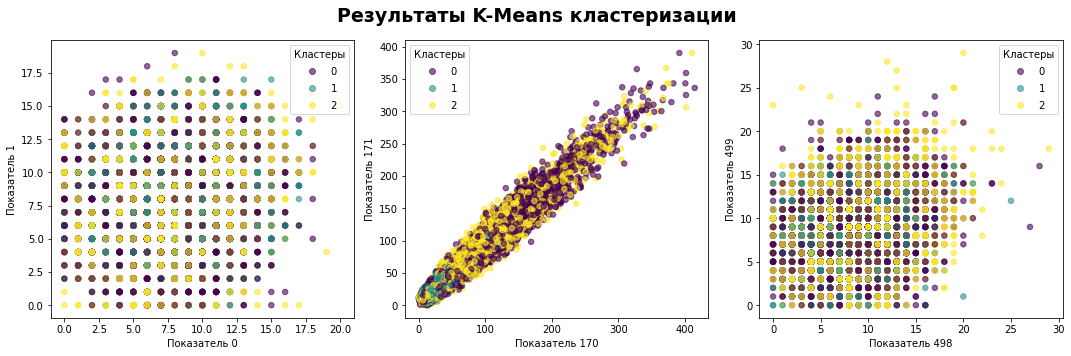

In [15]:
# Визуализируем результат кластеризации:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
plt.suptitle('Результаты K-Means кластеризации', fontsize=19, fontweight='bold')

scatter1 = axes[0].scatter(data.iloc[:, 0], data.iloc[:, 1], c=data['cluster'], cmap='viridis', s=30,
                           alpha=0.6)
axes[0].set_xlabel('Показатель 0')
axes[0].set_ylabel('Показатель 1')
axes[0].legend(*scatter1.legend_elements(), title='Кластеры')

scatter2 = axes[1].scatter(data.iloc[:, 170], data.iloc[:, 171], c=data['cluster'], cmap='viridis', s=30,
                           alpha=0.6)
axes[1].set_xlabel('Показатель 170')
axes[1].set_ylabel('Показатель 171')
axes[1].legend(*scatter2.legend_elements(), title='Кластеры')

scatter3 = axes[2].scatter(data.iloc[:, 498], data.iloc[:, 499], c=data['cluster'], cmap='viridis', s=30,
                           alpha=0.6)
axes[2].set_xlabel('Показатель 498')
axes[2].set_ylabel('Показатель 499')
axes[2].legend(*scatter3.legend_elements(), title='Кластеры')

plt.tight_layout()
plt.show()

Таким образом, лучшая модель кластеризации при оптимальной велечине длины хвоста позволила разделить сигналы на следующие три кластера, структура которых наиболее визуализируются на "хвостовом" участке:
- кластер 0: 10 702 сигнала (45,6% сигналов) - идентифицирован как нейтроны (характерно медленное затухание);
- кластер 1: 3 865 сигналов (16,5% сигналов) - идентифицирован как гамма-кванты (характерно быстрое затухание);
- кластер 2: 8 912 сигналов (37,9% сигналов) - аномальные/смешанные сигналы, требующие дополнительного анализа.

_Примечание: точное соотнесение кластеров с типами частиц требует верификации на размеченных данных._

___

## Формирование результатов

In [16]:
# Сохранение датасета:
predictions_total = data['cluster'].reset_index()

# Создаем маски для значений для преобразований:
mask_0 = predictions_total['cluster'] == 0
mask_1 = predictions_total['cluster'] == 1
mask_2 = predictions_total['cluster'] == 2

# Применяем инверсию:
predictions_total.loc[mask_0, 'cluster'] = 1
predictions_total.loc[mask_1, 'cluster'] = 2
predictions_total.loc[mask_2, 'cluster'] = 0

predictions_total.to_csv('submition_signal.csv', index=False)

try:
    if os.path.exists('submition_signal.csv'):
        print('Данные успешно сохранены.')
    
except Exception as error:
    print(f'Произошла ошибка сохранения данных: {error}.')

# Получение результата:
display(predictions_total.head())
display(predictions_total.tail())
print(f'Общее количество строк предсказаний: {len(predictions_total)}')

Данные успешно сохранены.


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


,index,cluster
23474,23474,0
23475,23475,0
23476,23476,0
23477,23477,0
23478,23478,1


Общее количество строк предсказаний: 23479


### Результат на kaggle

![Результаты кластеризации](Результаты_kaggle_кластеры.PNG)

---

## Общие выводы по результатам исследования

**По результатам исследования данных о сигналах, полученных со сцинтилляционного детектора, для целей обучения модели кластеризации указанных сигналов на три кластера, получены следующие выводы:**

<span style="background-color:#E8D3E3">1) Осуществлены загрузка и чтение исходных данных:</span>

**Предметная область исследования представлена одним датасетом** "Run200_Wave_0_1.txt", содержащим данные о сигналах, полученных со сцинтилляционного детектора.

Датасет содержит **23 479 записей в разрезе 500 показателей**.

**Для целей чтения и последующего исследования датасета:**
- показатели 0, 1, 2, 3 и 504 (технические данные) удалены из под целей дальнейшего рассмотрения в виду того, что первые 4 показателя имеют отличную от остальных показателей структуру данных (имеют другой масштаб), а последний - пустой;
- осуществлено инвертирование данных - вертикальное отражение сигнала относительно его максимального значения (превращение "впадин" в "пики", сохраняя форму сигнала), что связано со спецификой работы со сигналами - работают с "перевернутыми" данными.

**По результатам анализа данных:**
- пропуски данных отсутствуют;
- явные дубликаты не выявлены;
- типы данных оцениваются как соответсвующие.

**Таким образом, датасет содержит 23 479 строки, каждая из которых содержит информацию о конкретном сигнале в определенный момент времени (500 показателей).**

<span style="background-color:#E8D3E3">2) Осуществлен исследовательский анализ данных:</span>

**По результатам исследовательского анализа данных:**
- предметная область исследования представлена сигналами, сильно отличающимися по амплитуде и высоте;
- поведение сигналов стабильно на всем временном диапазоне (относительно нулевого уровня), вместе с тем в диапазоне показателей от 140 до 170 выявлено сильное "возмущение" - сосредоточение пиков сигналов;
- "отклики" такого возмущения прослеживаются вплоть до окончания представленного временного диапазона: с 0 по 141 показатели стандартное отклонение значений показателей стабильно и находится в диапазоне от 2.94 до 3, со 142 указанный показатель начинает повышаться, достигая своего пика в диапазоне 149-155 показателей и далее снова приходя в первоначальную норму, однако такое "затухание" проиходит крайне медленно.

**Учитывая вышеизложенное, представляется целесообразным для целей кластеризации сигналов сосредоточится на "хвосте" сигнала - значениях после пика "возмущения"**.<br>
Хвост сигнала после максимума действительно является важной характеристикой для кластеризации по нескольким причинам:
- описывает, как система возвращается в равновесное состояние после возмущения;
- инвариантен к начальным условиям (время пика, амплитуда);
- устойчив к шумам;
- компактен (меньше признаков);
- физически интерпретируем (характеризует внутренние свойства системы);
- разные процессы дают разные хвосты.

<span style="background-color:#E8D3E3">3) Осуществлен обоснованный отбор признаков для целей кластеризации:</span>

Для целей отбора признаков с учетом выбранного подхода - кластеризация на основе хвоста сигнала - значений после пика возмущения разработана функция, которая извлекает заданный участок сигнала после его максимума и возвращает нормированный относительно максимального значения хвоста хвост сигнала для каждой строки.

Функция предназначена для "извлечения" релаксационных процессов в импульсных сигналах: после возмущения (пика) система возвращается в равновесие, и форма этого возвращения (хвост) является характеристикой внутренних свойств системы.
    
Одновременно, каждый хвост приводится к диапазону от 0 до 1 (нормируется), что позволяет сравнивать форму затухания, игнорируя абсолютную амплитуду.

По результатам отбора признаков отобраны нормированные хвосты сигналов, равные 15-ти значениям после пика.<br>
Далее получены 8 главных компонент (птимальное количество компонент для сохранения 95% дисперсии).<br>
На первую компоненту наиболее влияют 8-мое, 7-мое, 9-тое, 10-тое и 6-тое значения после пика.

**Ключевые выводы из полученных результатов**:
- оптимальная длина хвоста - 15 значений после пика, так как захватывает переходную фазу (точки 1-5: начальная фаза затухания (быстрая); точки 6-10: переходная фаза (максимальная информативность) и точки 11-15: фаза установления (медленное затухание));
- точки 6-10 наиболее важны - это "золотая середина" хвоста;
- 8 компонент достаточно для 95% дисперсии - хорошее сжатие 15-ти признаков (первая компонента отражает скорость и характер затухания).

Таким образом, переходная область затухания (6-10 отсчетов) несет максимальную информацию о типе сигнала, что физически обосновано - в указанном диапазоне проявляются различия в механизмах релаксации.    

<span style="background-color:#E8D3E3">4) Осуществлено обучение нескольких моделей кластеризации:</span>

В рамках обучения моделей кластиризации обучены две модели: **KMeans() и DBSCAN()**.<br>
Какждая из моделей обучена отдельно, с подбором **нескольких гипперпараметров**.<br>
Сравнение моделей внутри группы (группа моделей KMeans() и DBSCAN() соответсвенно) осуществлено с помощью метрики качества кластеризации **silhouette scores** - коэффициент силуэта: показывает, насколько объект похож на свой кластер по сравнению с соседними кластерами.

**В рамках обучения моделей KMeans() получены следующие результаты:**
- Silhouette score = 0.334 - это хороший результат для реальных сигнальных данных;
- модель устойчива - разные параметры дают одинаковый результат;
- кластеры интерпретируемы и могут быть использованы для анализа;
- оптимальные параметры: algorithm='elkan', init='k-means++', max_iter=100, n_init=10.

**В рамках обучения моделей DBSCAN() получены следующие результаты:**
- лучший silhouette score: -0.477 (отрицательный = плохое качество);
- количество кластеров: 25-371 (нестабильно и много);
- доля шума: 30-54% данных (неприемлемо много);
- нет "решения" для целей кластеризации на три кластера.

Такие результаты могут быть обусловлены:
- непрерывная природа данных - хвосты сигналов образуют плавный континуум форм, без четких "разрывов" между кластерами;
- отсутствие естественных "островов" - DBSCAN ищет плотные области, разделенные пустотами, но в данных таких пустот нет;
- разная плотность кластеров - разные типы сигналов имеют разную вариативность, DBSCAN чувствителен к этому.

Таким образом, DBSCAN не подошел для целей поставленной задачи, в то время как K-means дает стабильные, интерпретируемые и качественные результаты.<br>
Увеличение длины хвоста дает небольшоей прирост качества кластеризации, вместе с тем, по результатам загрузки результатов на kaggle лучшим для поставленных проектом целей оказался хвост, длиною в 15 значений.

<span style="background-color:#E8D3E3">5) Получены метки кластеров при оптимальном подходе:</span>

Таким образом, лучшая модель кластеризации при оптимальной велечине длины хвоста позволила разделить сигналы на следующие три кластера, структура которых наиболее визуализируются на "хвостовом" участке:
- кластер 0: 10 702 сигнала (45,6% сигналов) - идентифицирован как нейтроны (характерно медленное затухание);
- кластер 1: 3 865 сигналов (16,5% сигналов) - идентифицирован как гамма-кванты (характерно быстрое затухание);
- кластер 2: 8 912 сигналов (37,9% сигналов) - аномальные/смешанные сигналы, требующие дополнительного анализа.

_Примечание: точное соотнесение кластеров с типами частиц требует верификации на размеченных данных._

<span style="background-color:#E8D3E3">6) Сформирован итоговый датасет с метками кластеров согласно требованиям и реализовано участие в соревновании на kaggle:</span>

Классификация сигналов на основе формы хвоста (15 отсчетов после пика) показала точность 73.7%, что значительно выше случайного угадывания (33.3% для 3 классов), - это подтверждает, что форма хвоста является информативным признаком для разделения гамма-квантов и нейтронов.

---